# 1.Configuration et imports

In [2]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

sys.path.append(str(Path("..").resolve()))
from src.data.loader import compute_train_rul, load_cmapss_subset

DATA_RAW = Path("../data/raw")
df_train, df_test, df_rul = load_cmapss_subset(DATA_RAW, subset="FD004")
df_train = compute_train_rul(df_train)

# Définition des groupes de colonnes
SETTINGS = ["setting_1", "setting_2", "setting_3"]
SENSORS = [c for c in df_train.columns if c.startswith("s_")]

print(f"Train chargé : {df_train.shape}")

Train chargé : (61249, 27)


# 2.Identification des 6 régimes

In [3]:
# 1. Scaling des settings
scaler_settings = StandardScaler()
train_settings_scaled = scaler_settings.fit_transform(df_train[SETTINGS])
test_settings_scaled = scaler_settings.transform(df_test[SETTINGS])

# 2. Clustering K-Means k=6
kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
df_train["op_regime"] = kmeans.fit_predict(train_settings_scaled)
df_test["op_regime"] = kmeans.predict(test_settings_scaled)

print("Répartition des régimes d'opérations (Train) :")
print(df_train["op_regime"].value_counts().sort_index())

Répartition des régimes d'opérations (Train) :
op_regime
0    15395
1     9224
2     9139
3     9091
4     9238
5     9162
Name: count, dtype: int64


In [4]:
# Pour chacun des 6 régimes et pour chaque capteurs, on calcule la moyenne et l'écart-type
regime_stats = (
    df_train.groupby("op_regime")[SENSORS].agg(["mean", "std"]).reset_index()
)


def normalize_by_regime(
    df: pd.DataFrame, stats: pd.DataFrame, sensors: list[str]
) -> pd.DataFrame:
  """Normalise chaque capteur selon la moyenne et l'écart-type de son régime opérationnel."""
  df_out = df.copy()

  for sensor in sensors:
    norm_col = f"{sensor}_norm"
    # Dictionnaire de mapping {regime: mean} et {regime: std}
    mean_map = stats.set_index("op_regime")[(sensor, "mean")].to_dict()
    std_map = stats.set_index("op_regime")[(sensor, "std")].to_dict()

    regime_mean = df_out["op_regime"].map(mean_map)
    regime_std = df_out["op_regime"].map(std_map).replace(0, 1.0)

    # Formule du z-score
    df_out[norm_col] = (df_out[sensor] - regime_mean) / regime_std

  return df_out


# Application
df_train_norm = normalize_by_regime(df_train, regime_stats, SENSORS)
df_test_norm = normalize_by_regime(df_test, regime_stats, SENSORS)

NORM_SENSORS = [f"{s}_norm" for s in SENSORS]
print(f"Exemple de capteurs normalisés : {NORM_SENSORS[:3]}")

Exemple de capteurs normalisés : ['s_1_norm', 's_2_norm', 's_3_norm']


# 3. Rooling features(Moyennes et écart-types mobiles par moteur)


In [5]:
WINDOW_SIZE = 15


def add_rolling_features(
    df: pd.DataFrame, cols: list[str], window: int = 15
) -> pd.DataFrame:
  """Calcule la moyenne mobile et l'écart-type mobile pour chaque moteur."""
  df_out = df.copy()

  # Regroupement par moteur pour ne jamais mélanger les trajectoires
  grouped = df_out.groupby("unit_id")[cols]

  # Moyennes mobiles
  rolling_mean = grouped.rolling(window=window, min_periods=1).mean().values
  mean_cols = [f"{c}_roll_mean_{window}" for c in cols]
  df_out[mean_cols] = rolling_mean

  # Écarts-types mobiles (imputer 0 pour le premier cycle où std est NaN)
  rolling_std = grouped.rolling(window=window, min_periods=1).std().values
  std_cols = [f"{c}_roll_std_{window}" for c in cols]
  df_out[std_cols] = np.nan_to_num(rolling_std, nan=0.0)

  return df_out


df_train_features = add_rolling_features(
    df_train_norm, NORM_SENSORS, window=WINDOW_SIZE
)
df_test_features = add_rolling_features(
    df_test_norm, NORM_SENSORS, window=WINDOW_SIZE
)

print(
    f"Dimensions après rolling features (Train) : {df_train_features.shape}"
)

Dimensions après rolling features (Train) : (61249, 91)


# 5. Plafonnement de la RUL

En pratique industrielle, un équipement neuf a un état de santé stable : sa dégradation n'est physique et mesurable qu'à partir d'un certain seuil. On applique un seuil maximal retenu dans la littérature pour C-MAPSS (clip à 125 cycles)

La phase saine (début de vie) :

Pendant les 100 ou 200 premiers cycles, le moteur est neuf. Les jeux mécaniques sont nominaux, il n'y a ni microfissure, ni encrassement thermique.

Le problème pour l'algorithme : les capteurs mesurent un moteur en parfait état, qu'il lui reste 400 cycles, 300 cycles ou 200 cycles à vivre. Demander à un modèle de deviner s'il reste 380 cycles ou 270 cycles à partir de signaux quasi-constants force le modèle à apprendre du pur bruit aléatoire.

La phase d'usure active (fin de vie) :

Une fois qu'une fissure apparaît ou que les aubes s'érodent, les températures et vibrations dérivent de façon visible et mesurable jusqu'à la rupture (RUL = 0).

En fixant RUL_CLIP = 125, on dit au modèle : 

« Si le moteur est sain, prédis simplement qu'il lui reste au moins 125 cycles. Dès que les capteurs dérivent et que l'usure commence, commence à estimer précisément le compte à rebours de 125 jusqu'à 0. »

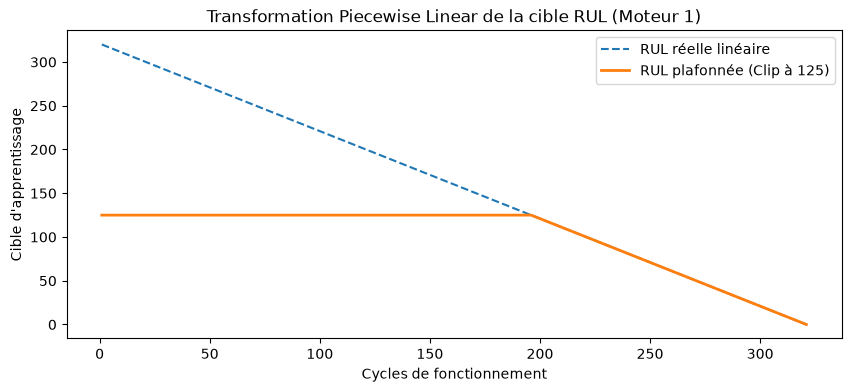

In [6]:
RUL_CLIP = 125

df_train_features["rul_clipped"] = df_train_features["rul"].clip(upper=RUL_CLIP)

# Visualisation pour le moteur 1
import matplotlib.pyplot as plt

m1 = df_train_features[df_train_features["unit_id"] == 1]
plt.figure(figsize=(10, 4))
plt.plot(m1["time_cycles"], m1["rul"], label="RUL réelle linéaire", ls="--")
plt.plot(
    m1["time_cycles"],
    m1["rul_clipped"],
    label=f"RUL plafonnée (Clip à {RUL_CLIP})",
    lw=2,
)
plt.title("Transformation Piecewise Linear de la cible RUL (Moteur 1)")
plt.xlabel("Cycles de fonctionnement")
plt.ylabel("Cible d'apprentissage")
plt.legend()
plt.show()

# 6. Sauvegarde des données transformées

In [7]:
DATA_PROCESSED = Path("../data/processed")
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)

df_train_features.to_parquet(
    DATA_PROCESSED / "train_FD004_features.parquet", index=False
)
df_test_features.to_parquet(
    DATA_PROCESSED / "test_FD004_features.parquet", index=False
)

print(
    f"Données sauvegardées avec succès dans {DATA_PROCESSED.resolve()} !"
)

Données sauvegardées avec succès dans C:\Users\aluss\predictive-maintenance-rul\data\processed !
